# Replicating Kilian (2007)

**Paper:** *Not All Oil Price Shocks Are Alike: Disentangling Demand and Supply Shocks in the Crude Oil Market*  
**Original codebase:** MATLAB files by Lutz Kilian (README + `figure2.m` to `figure5.m`, with helper functions).

This notebook translates the full MATLAB replication package into Python in one place.

In [32]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Optional style tweak for cleaner plots
plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = Path('/Users/tyau/Desktop/cornell course/spring/ECON 7300 bayes time series/project/lutz_kilian')
np.set_printoptions(suppress=True, precision=4)

## MATLAB to Python mapping

- `trivar.m` -> `trivar()`
- `olsvarc.m` -> `olsvarc()`
- `irfvar.m` -> `irfvar()`
- `stage2irf.m` -> `stage2irf()`
- `dif.m` -> `dif()`
- `vec.m` -> `vec()`
- `figure2.m` to `figure5.m` -> dedicated replication cells below

In [33]:
def vec(y: np.ndarray) -> np.ndarray:
    """MATLAB vec.m: column-wise vectorization."""
    return np.asarray(y).reshape(-1, 1, order='F')


def dif(y: np.ndarray) -> np.ndarray:
    """MATLAB dif.m: first differences along rows."""
    y = np.asarray(y)
    return y[1:, :] - y[:-1, :]


def olsvarc(y: np.ndarray, p: int):
    """MATLAB olsvarc.m: level VAR with intercept in companion format by OLS."""
    t, q = y.shape
    y_t = y.T

    # MATLAB: Y = y(:,p:t) with 1-based inclusive indexing.
    Y = y_t[:, p - 1:t]
    for i in range(1, p):
        # MATLAB: y(:,p-i:t-i)
        Y = np.vstack([Y, y_t[:, p - i - 1:t - i]])

    # Match MATLAB exactly:
    # X = [ones(1,t-p); Y(:,1:t-p)] and Y = Y(:,2:t-p+1)
    # -> both end up with (t-p) columns.
    X = np.vstack([np.ones((1, t - p)), Y[:, :t - p]])
    Y_dep = Y[:, 1:t - p + 1]

    A_full = (Y_dep @ X.T) @ np.linalg.inv(X @ X.T)
    U = Y_dep - A_full @ X
    sigma = (U @ U.T) / (t - p - p * q - 1)
    V = A_full[:, [0]]
    A = A_full[:, 1:q * p + 1]

    return A, sigma, U, V, X


def irfvar(A: np.ndarray, sigma: np.ndarray, p: int, h: int, q: int = 3) -> np.ndarray:
    """MATLAB irfvar.m equivalent with Cholesky identification.

    In Kilian's code, A is already the companion matrix of size (q*p, q*p).
    """
    qp = q * p

    # If a reduced-form top block is passed, convert it to companion form.
    if A.shape == (q, qp):
        top = A
        if p == 1:
            comp = top
        else:
            bottom = np.hstack([np.eye(q * (p - 1)), np.zeros((q * (p - 1), q))])
            comp = np.vstack([top, bottom])
    else:
        comp = A

    J = np.hstack([np.eye(q), np.zeros((q, qp - q))])
    C = np.linalg.cholesky(sigma).T

    irfs = []
    comp_power = np.eye(comp.shape[0])
    for _ in range(h + 1):
        resp = J @ comp_power @ J.T @ C
        irfs.append(resp.reshape(q * q, 1, order='F'))
        comp_power = comp_power @ comp

    return np.hstack(irfs)


def stage2irf(y: np.ndarray, q_shock: np.ndarray, nrep: int = 20_000, seed: int = 1234):
    """MATLAB stage2irf.m translation with block bootstrap."""
    y = np.asarray(y).reshape(-1, 1)
    q_shock = np.asarray(q_shock).reshape(-1, 1)

    t = len(q_shock)
    pp = 12

    Z = [np.ones((t - pp, 1))]
    for i in range(pp + 1):
        Z.append(q_shock[pp - i:t - i, :])
    Z = np.hstack(Z)

    y_dep = y[pp:t, :]

    bhat = np.linalg.inv(Z.T @ Z) @ Z.T @ y_dep
    ehat = y_dep - Z @ bhat

    irf1hat = bhat[1:, 0]
    cumirf1hat = np.cumsum(irf1hat)

    rng = np.random.default_rng(seed)
    IRF1 = np.zeros((nrep, 13))
    cumIRF1 = np.zeros((nrep, 13))

    block = 4
    y_len = len(y_dep)

    for j in range(nrep):
        yr_blocks, Zr_blocks = [], []
        n_blocks = int(np.ceil(y_len / block))
        for _ in range(n_blocks):
            pos = int(np.ceil(rng.random() * (len(ehat) - block)))
            start = max(0, min(pos - 1, len(ehat) - block))
            yr_blocks.append(y_dep[start:start + block, :])
            Zr_blocks.append(Z[start:start + block, :])

        yr = np.vstack(yr_blocks)[:y_len, :]
        Zr = np.vstack(Zr_blocks)[:y_len, :]

        br = np.linalg.inv(Zr.T @ Zr) @ Zr.T @ yr
        IRF1[j, :] = br[1:, 0]
        cumIRF1[j, :] = np.cumsum(IRF1[j, :])

    irf1std = IRF1.std(axis=0, ddof=1)
    irf1a = np.vstack([irf1hat + irf1std, irf1hat - irf1std])
    irf1b = np.vstack([irf1hat + 2 * irf1std, irf1hat - 2 * irf1std])

    cumirf1std = cumIRF1.std(axis=0, ddof=1)
    cumirf1a = np.vstack([cumirf1hat + cumirf1std, cumirf1hat - cumirf1std])
    cumirf1b = np.vstack([cumirf1hat + 2 * cumirf1std, cumirf1hat - 2 * cumirf1std])

    return irf1hat, irf1a, irf1b, cumirf1hat, cumirf1a, cumirf1b

In [34]:
def trivar(base_dir: Path = BASE_DIR):
    """MATLAB trivar.m translation."""
    y = np.loadtxt(base_dir / 'data.txt')
    t, q = y.shape
    timeline = np.arange(1973 + 2 / 12, 2007 + 12 / 12 + 1e-9, 1 / 12)
    h = 15
    p = 24

    A, sigma, Uhat, V, X = olsvarc(y, p)
    sigma = sigma[:q, :q]

    return {
        'y': y,
        't': t,
        'q': q,
        'time': timeline,
        'h': h,
        'p': p,
        'A': A,
        'SIGMA': sigma,
        'Uhat': Uhat,
        'V': V,
        'X': X,
    }


def compute_structural_shocks(SIGMA: np.ndarray, Uhat: np.ndarray):
    """Ehat = inv(chol(SIGMA)') * Uhat in MATLAB notation."""
    C = np.linalg.cholesky(SIGMA).T
    Ehat = np.linalg.solve(C, Uhat[:3, :])
    return Ehat


trv = trivar()
print(f"Loaded VAR data with shape: {trv['y'].shape}; p={trv['p']}, h={trv['h']}")

Loaded VAR data with shape: (419, 3); p=24, h=15


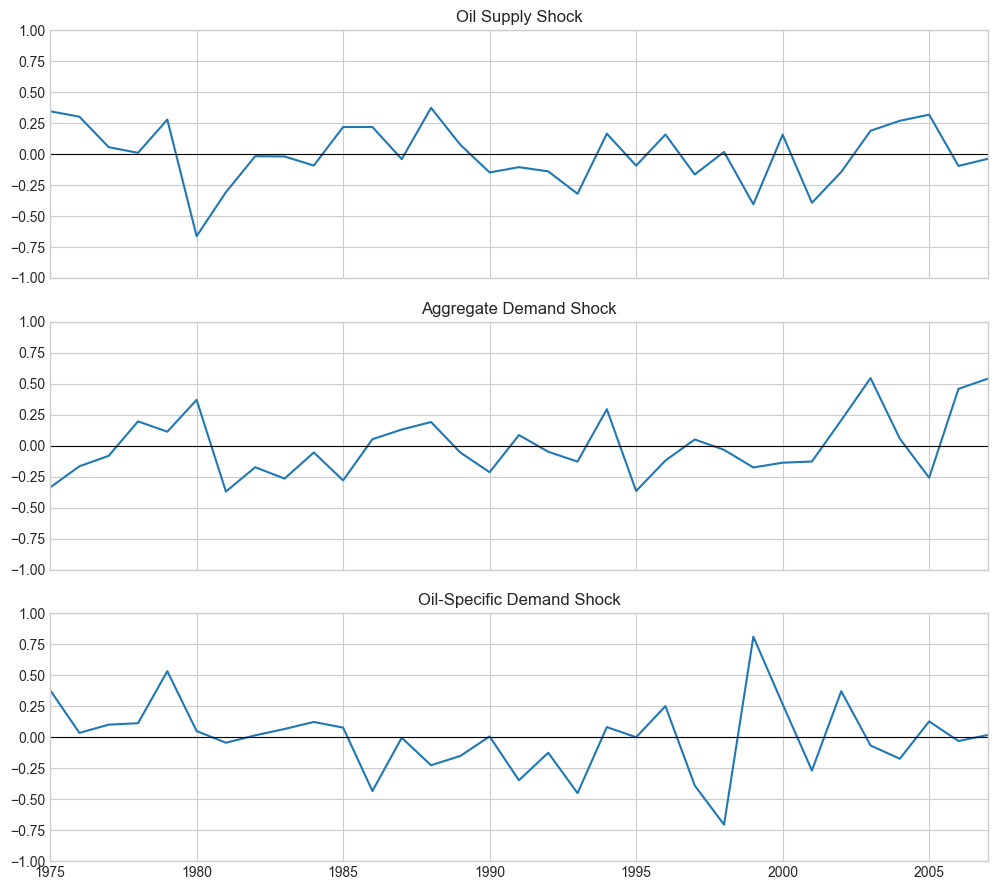

In [35]:
# Figure 2 replication
trv = trivar()
q = trv['q']

Ehat = compute_structural_shocks(trv['SIGMA'], trv['Uhat'])
q1, q2, q3 = Ehat[0, :], Ehat[1, :], Ehat[2, :]
q1 = np.concatenate([[(q1[0] + q1[1]) / 2], q1])
q2 = np.concatenate([[(q2[0] + q2[1]) / 2], q2])
q3 = np.concatenate([[(q3[0] + q3[1]) / 2], q3])

time_year = np.arange(1975, 2007 + 1)
q1a = q1[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q2a = q2[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q3a = q3[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(time_year, q1a)
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].set_title('Oil Supply Shock')
axes[0].set_xlim(1975, 2007)
axes[0].set_ylim(-1, 1)

axes[1].plot(time_year, q2a)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_title('Aggregate Demand Shock')
axes[1].set_xlim(1975, 2007)
axes[1].set_ylim(-1, 1)

axes[2].plot(time_year, q3a)
axes[2].axhline(0, color='k', linewidth=0.8)
axes[2].set_title('Oil-Specific Demand Shock')
axes[2].set_xlim(1975, 2007)
axes[2].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

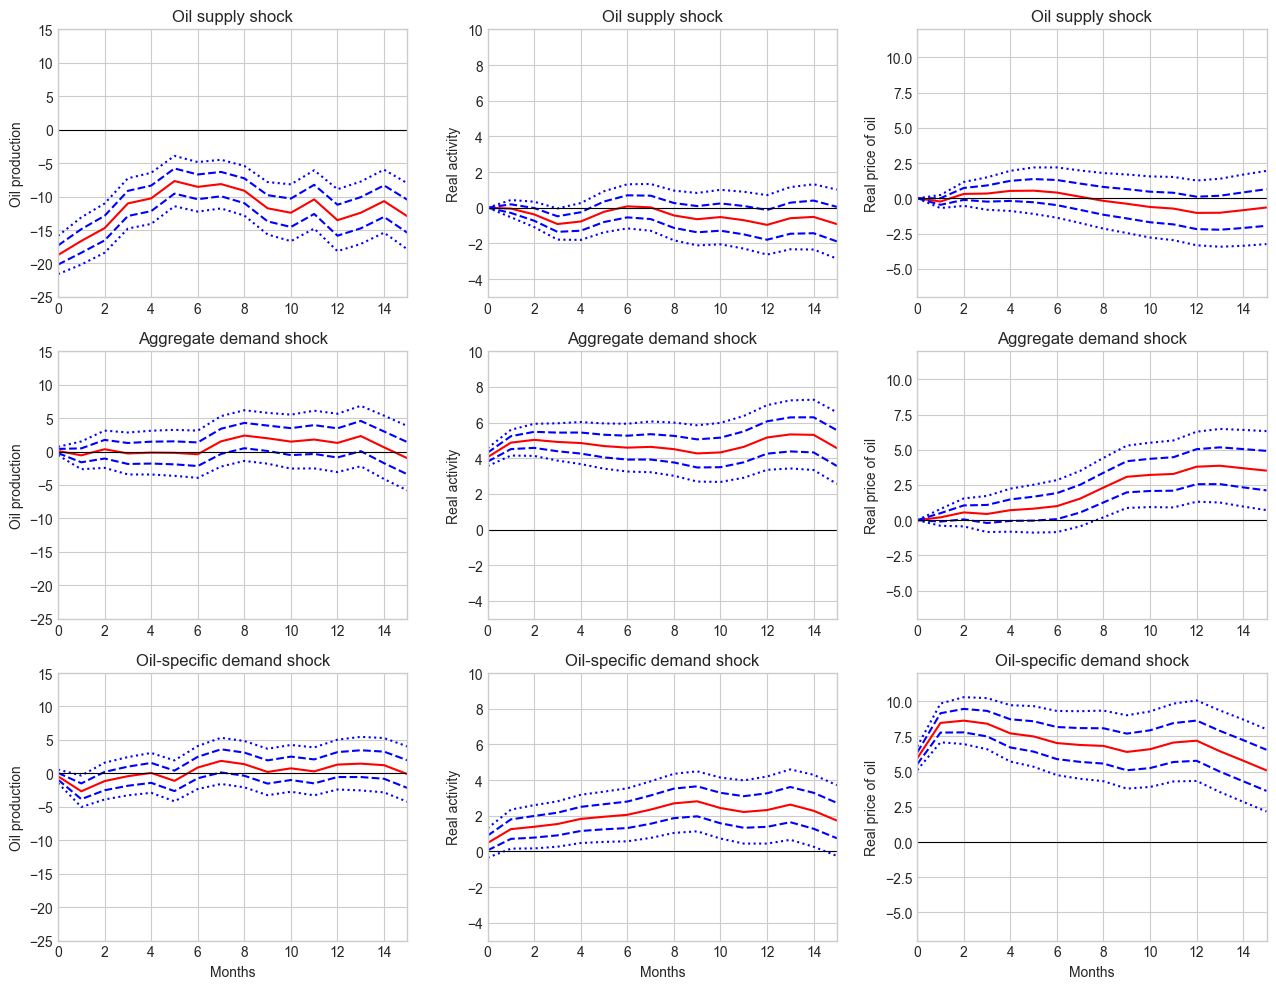

In [36]:
# Figure 3 replication
trv = trivar()
y = trv['y']
t, q = y.shape
p, h = trv['p'], trv['h']
A, SIGMA, Uhat, V = trv['A'], trv['SIGMA'], trv['Uhat'], trv['V']

IRF = irfvar(A, SIGMA[:q, :q], p, h, q=q)
IRF[0, :] = np.cumsum(IRF[0, :])
IRF[3, :] = np.cumsum(IRF[3, :])
IRF[6, :] = np.cumsum(IRF[6, :])

rng = np.random.default_rng(1234)
nrep = 2000
IRFmat = np.zeros((nrep, (q ** 2) * (h + 1)))

y_t = y.T
# MATLAB: Y=y(:,p:t); for i=1:p-1, Y=[Y; y(:,p-i:t-i)]
Y = y_t[:, p - 1:t]
for i in range(1, p):
    Y = np.vstack([Y, y_t[:, p - i - 1:t - i]])

U = Uhat.copy()
Ur = np.zeros((q * p, t - p + 1))
Yr = np.zeros((q * p, t - p + 1))

for r in range(nrep):
    pos = int(np.floor(rng.random() * (t - p + 1)))
    Yr[:, 0] = Y[:, pos]

    eta = rng.standard_normal(Uhat.shape[1])
    eta = np.vstack([eta, eta, eta])
    Ur[:q, 1:t - p + 1] = U[:q, :] * eta

    for i in range(1, t - p + 1):
        Yr[:, i] = (V[:, 0] + A @ Yr[:, i - 1] + Ur[:, i])

    yr = Yr[:q, :]
    for i in range(2, p + 1):
        yr = np.hstack([Yr[(i - 1) * q:i * q, [0]], yr])
    yr = yr.T

    Ar, SIGMAr, *_ = olsvarc(yr, p)

    IRFr = irfvar(Ar, SIGMAr[:q, :q], p, h, q=q)
    IRFr[0, :] = np.cumsum(IRFr[0, :])
    IRFr[3, :] = np.cumsum(IRFr[3, :])
    IRFr[6, :] = np.cumsum(IRFr[6, :])
    IRFmat[r, :] = vec(IRFr)[:, 0]

IRFrstd = np.std(IRFmat, axis=0, ddof=1).reshape(q ** 2, h + 1, order='F')
CI1LO, CI1UP = IRF - IRFrstd, IRF + IRFrstd
CI2LO, CI2UP = IRF - 2 * IRFrstd, IRF + 2 * IRFrstd

horizon = np.arange(0, h + 1)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()

series = [
    (-IRF[0], -CI1LO[0], -CI1UP[0], -CI2LO[0], -CI2UP[0], 'Oil supply shock', 'Oil production', (-25, 15)),
    (-IRF[1], -CI1LO[1], -CI1UP[1], -CI2LO[1], -CI2UP[1], 'Oil supply shock', 'Real activity', (-5, 10)),
    (-IRF[2], -CI1LO[2], -CI1UP[2], -CI2LO[2], -CI2UP[2], 'Oil supply shock', 'Real price of oil', (-7, 12)),
    ( IRF[3],  CI1LO[3],  CI1UP[3],  CI2LO[3],  CI2UP[3], 'Aggregate demand shock', 'Oil production', (-25, 15)),
    ( IRF[4],  CI1LO[4],  CI1UP[4],  CI2LO[4],  CI2UP[4], 'Aggregate demand shock', 'Real activity', (-5, 10)),
    ( IRF[5],  CI1LO[5],  CI1UP[5],  CI2LO[5],  CI2UP[5], 'Aggregate demand shock', 'Real price of oil', (-7, 12)),
    ( IRF[6],  CI1LO[6],  CI1UP[6],  CI2LO[6],  CI2UP[6], 'Oil-specific demand shock', 'Oil production', (-25, 15)),
    ( IRF[7],  CI1LO[7],  CI1UP[7],  CI2LO[7],  CI2UP[7], 'Oil-specific demand shock', 'Real activity', (-5, 10)),
    ( IRF[8],  CI1LO[8],  CI1UP[8],  CI2LO[8],  CI2UP[8], 'Oil-specific demand shock', 'Real price of oil', (-7, 12)),
]

for i, (m, c1l, c1u, c2l, c2u, ttl, yl, ylim) in enumerate(series):
    ax = axes[i]
    ax.plot(horizon, m, 'r-')
    ax.plot(horizon, c1l, 'b--')
    ax.plot(horizon, c1u, 'b--')
    ax.plot(horizon, c2l, 'b:')
    ax.plot(horizon, c2u, 'b:')
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, h)
    ax.set_ylim(*ylim)
    if i >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

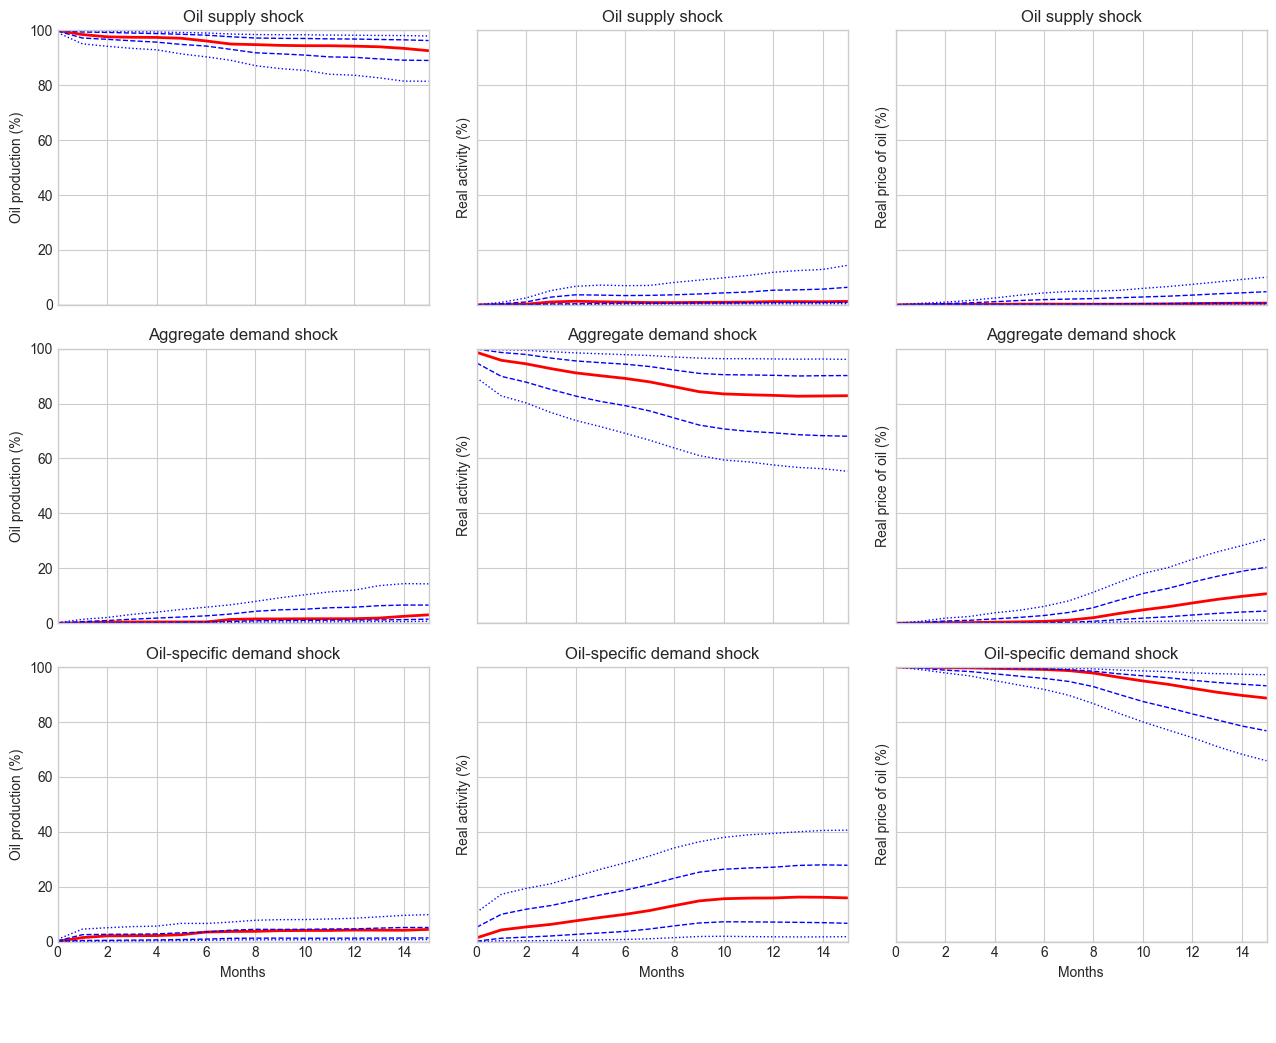

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%
Real activity: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%
Real price of oil: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%


In [37]:
# FEVD computation from IRF results

# Reshape IRF to compute FEVD
# IRF can be overwritten in later cells; build a local IRF at horizon h.
IRF_fevd = irfvar(A, SIGMA[:q, :q], p, h, q=q)
IRF_fevd = np.asarray(IRF_fevd).reshape(-1, order='F')
expected_len = (q ** 2) * (h + 1)
if IRF_fevd.size != expected_len:
    raise ValueError(
        f"IRF_fevd has {IRF_fevd.size} elements, expected {expected_len}. "
        "Re-run the VAR/IRF cell (with horizon h) before FEVD."
    )

# We need FEVD[shock, variable, horizon]
psi = IRF_fevd.reshape(q, q, h + 1, order='F').transpose(1, 0, 2)

# Cumulative squared impulse responses
cum_sq = np.cumsum(psi ** 2, axis=2)

# Denominator: sum across all shocks
denom = np.sum(cum_sq, axis=0, keepdims=True)

# FEVD: fraction of variance explained by each shock
# Avoid divide-by-zero at early horizons
FEVD = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

# Also compute FEVD for the bootstrap replicates (for alternative credible bands)
FEVDmat = np.zeros((nrep, q, q, h + 1))
for r in range(nrep):
    psi_r = IRFmat[r, :].reshape(q, q, h + 1, order='F').transpose(1, 0, 2)
    cum_sq_r = np.cumsum(psi_r ** 2, axis=2)
    denom_r = np.sum(cum_sq_r, axis=0, keepdims=True)
    FEVDmat[r] = np.divide(cum_sq_r, denom_r, out=np.zeros_like(cum_sq_r), where=denom_r > 0)

# Compute credible bands from bootstrap replicates
FEVD_lo68 = np.quantile(FEVDmat, 0.16, axis=0)
FEVD_hi68 = np.quantile(FEVDmat, 0.84, axis=0)
FEVD_lo95 = np.quantile(FEVDmat, 0.025, axis=0)
FEVD_hi95 = np.quantile(FEVDmat, 0.975, axis=0)

# Plot FEVD with bands
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock', 'Oil production'),
    ('Oil supply shock', 'Real activity'),
    ('Oil supply shock', 'Real price of oil'),
    ('Aggregate demand shock', 'Oil production'),
    ('Aggregate demand shock', 'Real activity'),
    ('Aggregate demand shock', 'Real price of oil'),
    ('Oil-specific demand shock', 'Oil production'),
    ('Oil-specific demand shock', 'Real activity'),
    ('Oil-specific demand shock', 'Real price of oil'),
]

for k, (ttl, yl) in enumerate(meta):
    shock = k // q
    var = k % q

    med = 100.0 * FEVD[shock, var, :]
    lo68 = 100.0 * FEVD_lo68[shock, var, :]
    hi68 = 100.0 * FEVD_hi68[shock, var, :]
    lo95 = 100.0 * FEVD_lo95[shock, var, :]
    hi95 = 100.0 * FEVD_hi95[shock, var, :]

    ax = axes[k]
    ax.plot(horizon, med, 'r-', linewidth=2)
    ax.plot(horizon, lo68, 'b--', linewidth=1)
    ax.plot(horizon, hi68, 'b--', linewidth=1)
    ax.plot(horizon, lo95, 'b:', linewidth=1)
    ax.plot(horizon, hi95, 'b:', linewidth=1)
    # ax.fill_between(horizon, lo68, hi68, alpha=0.3, color='blue', label='68% CB')
    # ax.fill_between(horizon, lo95, hi95, alpha=0.15, color='blue', label='95% CB')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3)
plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
for var in range(q):
    var_names = ['Oil production', 'Real activity', 'Real price of oil']
    fevd_sum = np.sum(FEVD[:, var, :], axis=0) * 100
    print(f"{var_names[var]}: h=0: {fevd_sum[0]:.1f}%, h=6: {fevd_sum[6]:.1f}%, h=15: {fevd_sum[15]:.1f}%")

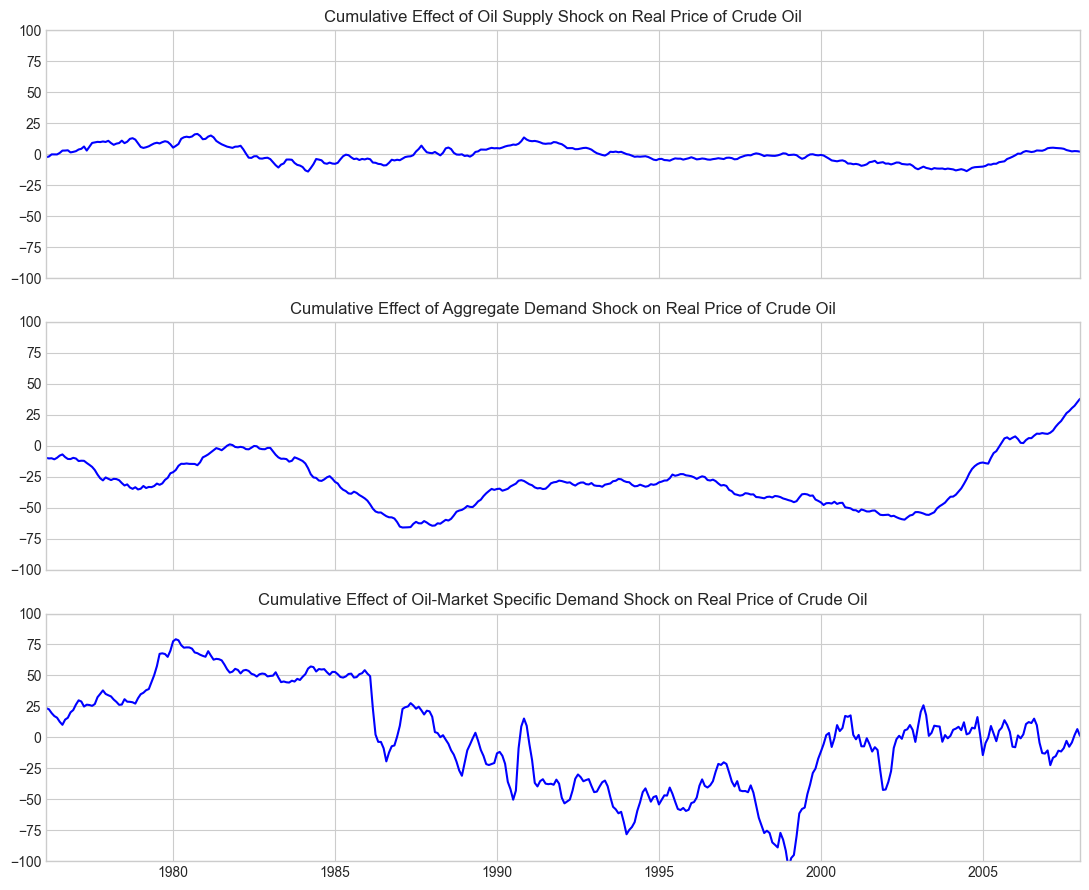

In [38]:
# Figure 4 replication
trv = trivar()
t, q = trv['t'], trv['q']
p = trv['p']

IRF = irfvar(trv['A'], trv['SIGMA'][:q, :q], p, t - p - 1, q=q)
Ehat = compute_structural_shocks(trv['SIGMA'], trv['Uhat'])

yhat1 = np.zeros(t - p)
yhat2 = np.zeros(t - p)
yhat3 = np.zeros(t - p)

for i in range(t - p):
    idx = np.arange(i + 1)
    yhat1[i] = np.dot(IRF[2, idx], Ehat[0, i::-1])
    yhat2[i] = np.dot(IRF[5, idx], Ehat[1, i::-1])
    yhat3[i] = np.dot(IRF[8, idx], Ehat[2, i::-1])

time = np.arange(1975 + 2 / 12, 2007 + 12 / 12 + 1e-9, 1 / 12)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(time, yhat1, 'b-')
axes[0].set_title('Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil')
axes[0].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[0].set_ylim(-100, 100)

axes[1].plot(time, yhat2, 'b-')
axes[1].set_title('Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil')
axes[1].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[1].set_ylim(-100, 100)

axes[2].plot(time, yhat3, 'b-')
axes[2].set_title('Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil')
axes[2].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[2].set_ylim(-100, 100)

plt.tight_layout()
plt.show()

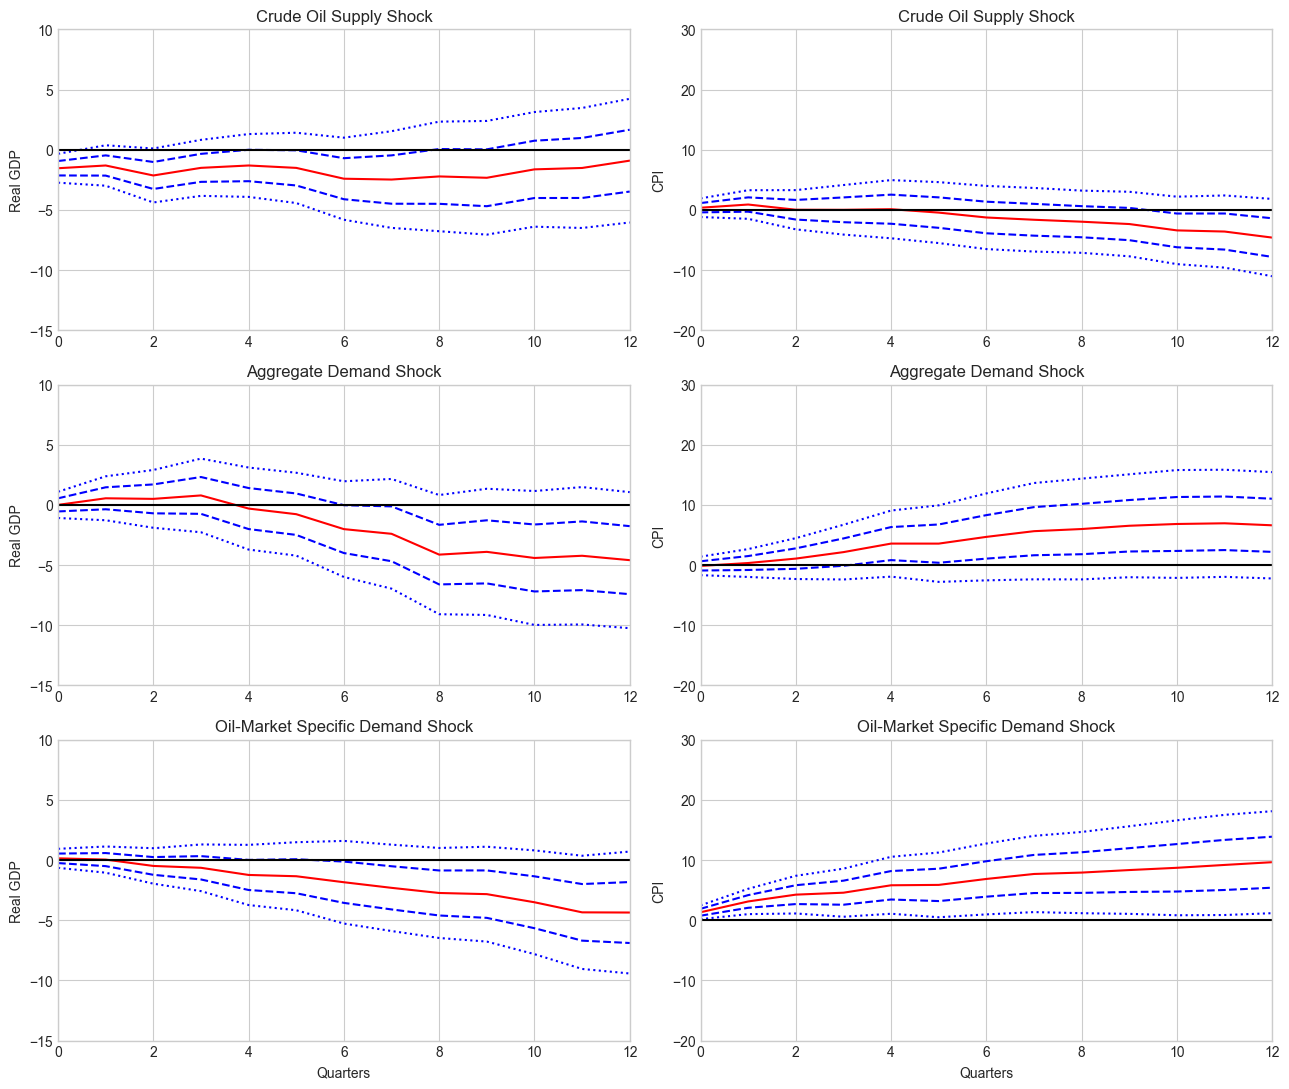

In [41]:
# Figure 5 replication
# Note: nrep_stage2=20000 matches MATLAB and can take time.
nrep_stage2 = 20_000

trv = trivar()
Ehat = compute_structural_shocks(trv['SIGMA'], trv['Uhat'])

q1 = np.concatenate([[(Ehat[0, 0] + Ehat[0, 1]) / 2], Ehat[0, :]])
q2 = np.concatenate([[(Ehat[1, 0] + Ehat[1, 1]) / 2], Ehat[1, :]])
q3 = np.concatenate([[(Ehat[2, 0] + Ehat[2, 1]) / 2], Ehat[2, :]])

quarter_time = np.arange(1975 + 1 / 4, 2007 + 4 / 4 + 1e-9, 1 / 4)
nq = len(quarter_time)

q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# Real GDP (BEA file)
beagdp = np.loadtxt(BASE_DIR / 'beagdp.txt')
gdp = beagdp[:, 2]
y_gdp = dif(np.log(gdp).reshape(-1, 1)) * 400

h2 = np.arange(0, 13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

irf2hat, irf2a, irf2b, cumirf2hat, cumirf2a, cumirf2b = stage2irf(y_gdp, q1q, nrep=nrep_stage2, seed=42)
axes[0, 0].plot(h2, -cumirf2hat, 'r-', h2, -cumirf2a[0], 'b--', h2, -cumirf2a[1], 'b--', h2, -cumirf2b[0], 'b:', h2, -cumirf2b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[0, 0].set_xlim(0, 12); axes[0, 0].set_ylim(-15, 10)
axes[0, 0].set_ylabel('Real GDP'); axes[0, 0].set_title('Crude Oil Supply Shock')

irf3hat, irf3a, irf3b, cumirf3hat, cumirf3a, cumirf3b = stage2irf(y_gdp, q2q, nrep=nrep_stage2, seed=42)
axes[1, 0].plot(h2, cumirf3hat, 'r-', h2, cumirf3a[0], 'b--', h2, cumirf3a[1], 'b--', h2, cumirf3b[0], 'b:', h2, cumirf3b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[1, 0].set_xlim(0, 12); axes[1, 0].set_ylim(-15, 10)
axes[1, 0].set_ylabel('Real GDP'); axes[1, 0].set_title('Aggregate Demand Shock')

irf4hat, irf4a, irf4b, cumirf4hat, cumirf4a, cumirf4b = stage2irf(y_gdp, q3q, nrep=nrep_stage2, seed=42)
axes[2, 0].plot(h2, cumirf4hat, 'r-', h2, cumirf4a[0], 'b--', h2, cumirf4a[1], 'b--', h2, cumirf4b[0], 'b:', h2, cumirf4b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[2, 0].set_xlim(0, 12); axes[2, 0].set_ylim(-15, 10)
axes[2, 0].set_ylabel('Real GDP'); axes[2, 0].set_title('Oil-Market Specific Demand Shock')
axes[2, 0].set_xlabel('Quarters')

# CPI inflation (FRED file)
cpi_raw = np.loadtxt(BASE_DIR / 'cpi.txt')
cpi = np.log(cpi_raw[:, 2])
# MATLAB: infl(i) = (cpi(i*3+1) - cpi((i-1)*3+1))*400, i=1..nq (1-based)
# Python 0-based equivalent: cpi[3*i] - cpi[3*(i-1)]
infl = np.array([(cpi[3 * i] - cpi[3 * (i - 1)]) * 400 for i in range(1, len(quarter_time) + 1)])
y_cpi = infl.reshape(-1, 1)

irf2hat, irf2a, irf2b, cumirf2hat, cumirf2a, cumirf2b = stage2irf(y_cpi, q1q, nrep=nrep_stage2, seed=42)
axes[0, 1].plot(h2, -cumirf2hat, 'r-', h2, -cumirf2a[0], 'b--', h2, -cumirf2a[1], 'b--', h2, -cumirf2b[0], 'b:', h2, -cumirf2b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[0, 1].set_xlim(0, 12); axes[0, 1].set_ylim(-20, 30)
axes[0, 1].set_ylabel('CPI'); axes[0, 1].set_title('Crude Oil Supply Shock')

irf3hat, irf3a, irf3b, cumirf3hat, cumirf3a, cumirf3b = stage2irf(y_cpi, q2q, nrep=nrep_stage2, seed=42)
axes[1, 1].plot(h2, cumirf3hat, 'r-', h2, cumirf3a[0], 'b--', h2, cumirf3a[1], 'b--', h2, cumirf3b[0], 'b:', h2, cumirf3b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[1, 1].set_xlim(0, 12); axes[1, 1].set_ylim(-20, 30)
axes[1, 1].set_ylabel('CPI'); axes[1, 1].set_title('Aggregate Demand Shock')

irf4hat, irf4a, irf4b, cumirf4hat, cumirf4a, cumirf4b = stage2irf(y_cpi, q3q, nrep=nrep_stage2, seed=42)
axes[2, 1].plot(h2, cumirf4hat, 'r-', h2, cumirf4a[0], 'b--', h2, cumirf4a[1], 'b--', h2, cumirf4b[0], 'b:', h2, cumirf4b[1], 'b:', h2, np.zeros_like(h2), 'k-')
axes[2, 1].set_xlim(0, 12); axes[2, 1].set_ylim(-20, 30)
axes[2, 1].set_ylabel('CPI'); axes[2, 1].set_title('Oil-Market Specific Demand Shock')
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.show()

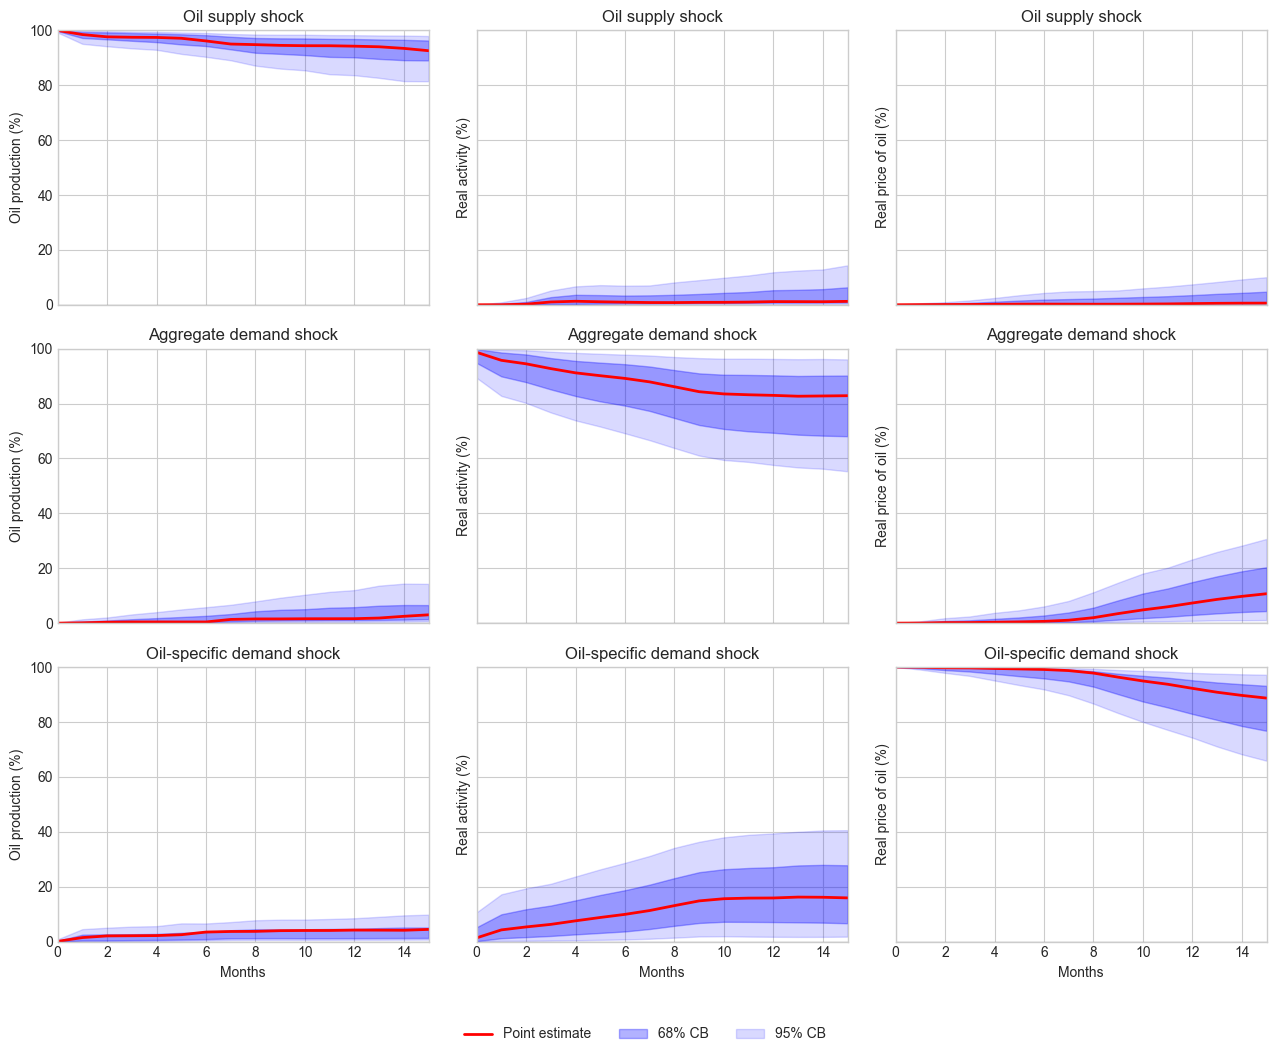

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%
Real activity: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%
Real price of oil: h=0: 100.0%, h=6: 100.0%, h=15: 100.0%


In [40]:
# FEVD computation from IRF results (robust to IRF being overwritten)

# IRF can be overwritten in later cells (e.g., with horizon t-p-1).
# Build a local IRF for FEVD at the intended horizon h.
try:
    IRF_fevd = irfvar(A, SIGMA[:q, :q], p, h, q=q)
except Exception:
    IRF_fevd = IRF

IRF_fevd = np.asarray(IRF_fevd)
if IRF_fevd.ndim == 2:
    IRF_fevd = IRF_fevd.reshape(-1, order='F')

expected_len = (q ** 2) * (h + 1)
if IRF_fevd.size != expected_len:
    raise ValueError(
        f"IRF_fevd has {IRF_fevd.size} elements, expected {expected_len}. "
        "Re-run the VAR/IRF cell (with horizon h) before FEVD."
    )

# Reshape to (shock, variable, horizon)
psi = IRF_fevd.reshape(q, q, h + 1, order='F').transpose(1, 0, 2)

# Cumulative squared impulse responses
cum_sq = np.cumsum(psi ** 2, axis=2)

# Denominator: sum across all shocks
denom = np.sum(cum_sq, axis=0, keepdims=True)

# FEVD: fraction of variance explained by each shock
FEVD = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

# Bootstrap FEVD (IRFmat is stored as flattened vectors)
IRFmat = np.asarray(IRFmat)
if IRFmat.ndim != 2:
    raise ValueError(f"IRFmat must be 2D, got shape {IRFmat.shape}")

nrep = IRFmat.shape[0]
if IRFmat.shape[1] != expected_len:
    raise ValueError(
        f"IRFmat has width {IRFmat.shape[1]}, expected {expected_len}. "
        "Re-run bootstrap IRF generation with horizon h."
    )

FEVDmat = np.zeros((nrep, q, q, h + 1))
for r in range(nrep):
    psi_r = IRFmat[r, :].reshape(q, q, h + 1, order='F').transpose(1, 0, 2)
    cum_sq_r = np.cumsum(psi_r ** 2, axis=2)
    denom_r = np.sum(cum_sq_r, axis=0, keepdims=True)
    FEVDmat[r] = np.divide(cum_sq_r, denom_r, out=np.zeros_like(cum_sq_r), where=denom_r > 0)

# Compute credible bands from bootstrap replicates
FEVD_lo68 = np.quantile(FEVDmat, 0.16, axis=0)
FEVD_hi68 = np.quantile(FEVDmat, 0.84, axis=0)
FEVD_lo95 = np.quantile(FEVDmat, 0.025, axis=0)
FEVD_hi95 = np.quantile(FEVDmat, 0.975, axis=0)

# Plot FEVD with bands
horizon = np.arange(h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock', 'Oil production'),
    ('Oil supply shock', 'Real activity'),
    ('Oil supply shock', 'Real price of oil'),
    ('Aggregate demand shock', 'Oil production'),
    ('Aggregate demand shock', 'Real activity'),
    ('Aggregate demand shock', 'Real price of oil'),
    ('Oil-specific demand shock', 'Oil production'),
    ('Oil-specific demand shock', 'Real activity'),
    ('Oil-specific demand shock', 'Real price of oil'),
]

for k, (ttl, yl) in enumerate(meta):
    shock = k // q
    var = k % q

    med = 100.0 * FEVD[shock, var, :]
    lo68 = 100.0 * FEVD_lo68[shock, var, :]
    hi68 = 100.0 * FEVD_hi68[shock, var, :]
    lo95 = 100.0 * FEVD_lo95[shock, var, :]
    hi95 = 100.0 * FEVD_hi95[shock, var, :]

    ax = axes[k]
    ax.plot(horizon, med, 'r-', linewidth=2, label='Point estimate')
    ax.fill_between(horizon, lo68, hi68, alpha=0.3, color='blue', label='68% CB')
    ax.fill_between(horizon, lo95, hi95, alpha=0.15, color='blue', label='95% CB')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3)
plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
var_names = ['Oil production', 'Real activity', 'Real price of oil']
check_horizons = [0, min(6, h), h]
for var in range(q):
    fevd_sum = np.sum(FEVD[:, var, :], axis=0) * 100
    msg = ", ".join([f"h={hh}: {fevd_sum[hh]:.1f}%" for hh in check_horizons])
    print(f"{var_names[var]}: {msg}")